In [1]:
import re
import nltk
import string
import fasttext
from nltk.corpus import stopwords

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from keras.models import Model
from keras.utils import pad_sequences
from keras.preprocessing.text import Tokenizer
from keras.layers import Conv1D, MaxPooling1D, Embedding, Concatenate, Dense, Input, Flatten

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [22]:
Max_sequence_length = 100
Embedding_dim = 100

In [20]:
data = pd.read_csv('ISEAR_Dataset.csv')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7516 entries, 0 to 7515
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   sentiment   7516 non-null   object
 1   content     7516 non-null   object
 2   Unnamed: 2  3 non-null      object
dtypes: object(3)
memory usage: 176.3+ KB


In [7]:
def actual_tag(string):
    if string.startswith('J'):
        return nltk.corpus.wordnet.ADJ
    elif string.startswith('V'):
        return nltk.corpus.wordnet.VERB
    elif string.startswith('N'):
        return nltk.corpus.wordnet.NOUN
    elif string.startswith('R'):
        return nltk.corpus.wordnet.ADV
    else:
        return nltk.corpus.wordnet.NOUN

In [8]:
def lemmatize(array):
    opt_list = []
    wl = nltk.WordNetLemmatizer()
    stop = stopwords.words('english')
    stop += list(string.punctuation)
    for tple in array:
        word, tag = tple
        if word.lower() not in stop and word.isalpha():
            temp = wl.lemmatize(word,actual_tag(tag))
            opt_list.append(temp.lower())
    return opt_list

In [9]:
def preprocess(text):
    text = nltk.tokenize.word_tokenize(text)
    text = nltk.pos_tag(text)
    text = lemmatize(text)
    return text

In [12]:
processed_data = data['content'].map(preprocess)

In [13]:
processed_data.head()

0    [day, feel, close, partner, friend, feel, peac...
1    [every, time, imagine, someone, love, could, c...
2    [obviously, unjustly, treat, possibility, eluc...
3    [think, short, time, live, relate, period, lif...
4    [gathering, find, involuntarily, sit, next, tw...
Name: content, dtype: object

In [14]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(processed_data)
sequences = tokenizer.texts_to_sequences(processed_data)

word_index = tokenizer.word_index
len(word_index)

7020

In [15]:
features = pad_sequences(sequences, Max_sequence_lengh)
labels = pd.get_dummies(data['sentiment'])
features.shape, labels.shape

((7516, 100), (7516, 7))

In [16]:
labels.head()

,anger,disgust,fear,guilt,joy,sadness,shame
0,0,0,0,0,1,0,0
1,0,0,1,0,0,0,0
2,1,0,0,0,0,0,0
3,0,0,0,0,0,1,0
4,0,1,0,0,0,0,0


In [17]:
x_train, x_test, y_train, y_test = train_test_split(features, labels, test_size = 0.2, random_state = 20)
x_test, x_val, y_test, y_val = train_test_split( features, labels, test_size=0.50, random_state=4)
x_train.shape, x_test.shape, x_val.shape, y_train.shape, y_test.shape, y_val.shape

((6012, 100), (3758, 100), (3758, 100), (6012, 7), (3758, 7), (3758, 7))

In [24]:
embd_model = fasttext.load_model(r"D:\Notebook\Projects\Embedding_Models\fasttext_embedding_model.bin")
embedding_matrix = np.zeros((len(word_index)+1, Embedding_dim))

for word,i in word_index.items():
    vector = embd_model.get_word_vector(word)
    if vector is not None:
        embedding_matrix[i] = vector

embedding_layer = Embedding(len(word_index)+1,Embedding_dim, weights = [embedding_matrix],
                            input_length=Max_sequence_length)

In [31]:
convs = []
filter_sizes = [3,4,5]

sequence_input = Input(shape=(Max_sequence_length,))
embedded_sequences = embedding_layer(sequence_input)

for fsz in filter_sizes:
    l_conv = Conv1D(128,fsz,activation='relu')(embedded_sequences)
    l_pool = MaxPooling1D(5)(l_conv)
    convs.append(l_pool)   
l_merge = Concatenate()(convs)
l_cov1= Conv1D(filters=128, kernel_size=5, activation='relu')(l_merge)
l_pool1 = MaxPooling1D(5)(l_cov1)
# l_cov2 = Conv1D(filters=128, kernel_size=5, activation='relu')(l_pool1)
# l_pool2 = MaxPooling1D(30)(l_cov2)
l_flat = Flatten()(l_pool1)
l_dense = Dense(128, activation='relu')(l_flat)
preds = Dense(7, activation='softmax')(l_dense)

model = Model(sequence_input, preds)
model.compile(loss='binary_crossentropy',
              optimizer='Nadam',
              metrics=['acc'])

model.summary()


Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 100)]                0         []                            
                                                                                                  
 embedding_1 (Embedding)     (None, 100, 100)             702100    ['input_3[0][0]']             
                                                                                                  
 conv1d_4 (Conv1D)           (None, 98, 128)              38528     ['embedding_1[2][0]']         
                                                                                                  
 conv1d_5 (Conv1D)           (None, 97, 128)              51328     ['embedding_1[2][0]']         
                                                                                            

In [36]:
history = model.fit(x_train,y_train , validation_data=(x_val,y_val), epochs=15, batch_size=150, verbose=1)

Epoch 1/15
41/41 [==============================] - 7s 171ms/step - loss: 0.0082 - acc: 0.9857 - val_loss: 0.1793 - val_acc: 0.8925
Epoch 2/15
41/41 [==============================] - 6s 151ms/step - loss: 0.0094 - acc: 0.9854 - val_loss: 0.2214 - val_acc: 0.8779
Epoch 3/15
41/41 [==============================] - 6s 155ms/step - loss: 0.0437 - acc: 0.9661 - val_loss: 0.1402 - val_acc: 0.8912
Epoch 4/15
41/41 [==============================] - 7s 160ms/step - loss: 0.0126 - acc: 0.9854 - val_loss: 0.1517 - val_acc: 0.8936
Epoch 5/15
41/41 [==============================] - 6s 152ms/step - loss: 0.0093 - acc: 0.9855 - val_loss: 0.1616 - val_acc: 0.8938
Epoch 6/15
41/41 [==============================] - 6s 156ms/step - loss: 0.0083 - acc: 0.9862 - val_loss: 0.1690 - val_acc: 0.8944
Epoch 7/15
41/41 [==============================] - 6s 145ms/step - loss: 0.0081 - acc: 0.9865 - val_loss: 0.1696 - val_acc: 0.8922
Epoch 8/15
41/41 [==============================] - 6s 156ms/step - loss: 0.

dict_keys(['loss', 'acc', 'val_loss', 'val_acc'])


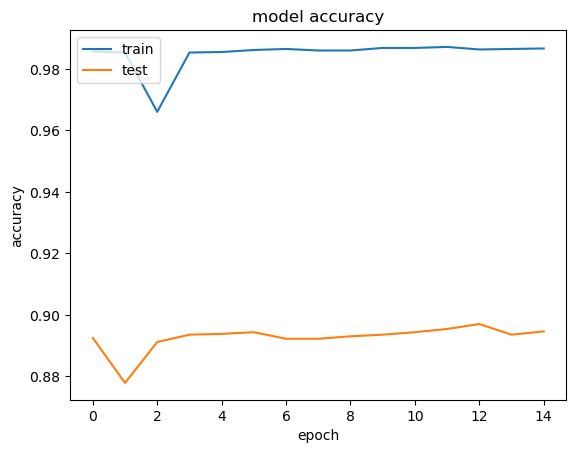

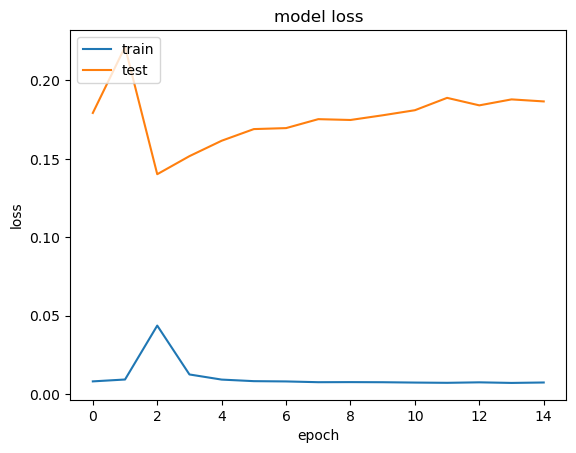

In [37]:
import matplotlib.pyplot as plt
%matplotlib inline 
# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [67]:
y_pred = model.predict(x_test, verbose=1)

118/118 [==============================] - 1s 8ms/step


In [77]:
arr = np.argmax(np.asarray(y_test), axis=1)
ans = np.argmax(y_pred, axis=1)
f1 = f1_score(arr,ans, average='micro')
r1 = recall_score(arr, ans, average='micro')
p1 = precision_score(arr,ans, average='micro')
acc = accuracy_score(arr,ans)
print('f1',f1)
print('r1',r1)
print('p1',p1)
print('acc',acc)

f1 0.8946248004257584
r1 0.8946248004257584
p1 0.8946248004257584
acc 0.8946248004257584


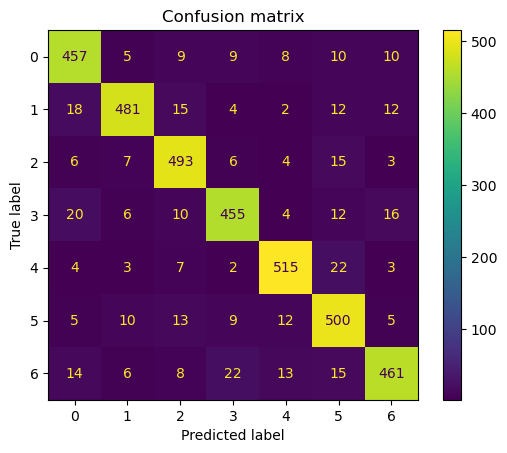

In [76]:
cm = confusion_matrix(arr, ans)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(set(arr)))
disp.plot()
plt.title("Confusion matrix")
plt.show()

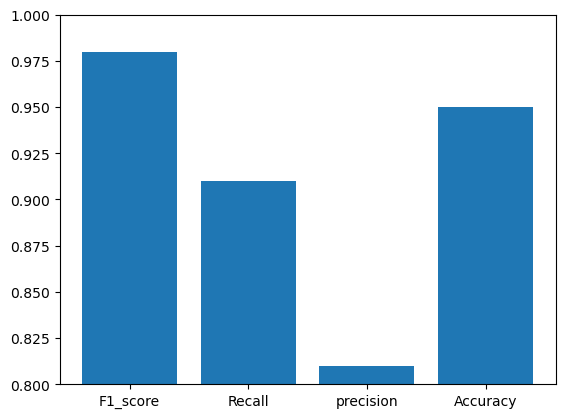

In [5]:
x = np.array(["F1_score", "Recall", "precision", "Accuracy"])
y = np.array([0.98, 0.91, .81, .95])

plt.bar(x,y)
plt.ylim(.8, 1)
plt.show()